In [106]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dronehover.optimization import Hover
from dronehover.bodies.standard_bodies import Quadcopter
from nsgaevo.phenotype import Phenotype_2D, Phenotype_3D
import plotly.graph_objects as go

plt.style.use("custom.mplstyle")

In [107]:
from scipy.spatial import ConvexHull
# Load standard quadcopter for comparison
quadcopter = Quadcopter(0.110)
sim = Hover(quadcopter)
sim.compute_hover(verbose=True)
print(sim.Bf)
quad_alpha = sim.alpha
quad_ctrl = min(sim.eig_m)
# quad_ctrl = np.exp(np.mean(np.log(sim.eig_m)))


# quad_size = 0.220*np.sin(np.pi/4) * 0.220*np.sin(np.pi/4)

points = []
for prop in quadcopter.props:
    points.append(prop["loc"])
points.append([0, 0, 0])    # Include origin
points.append([0.045, 0, 0.1]) # Include points for drone main body
points.append([-0.045, 0, 0.1]) # Include points for drone main body
points.append([0, 0.045, 0.1]) # Include points for drone main body
points.append([0, -0.045, 0.1]) # Include points for drone main body
points = np.array(points)
hull = ConvexHull(points)
quad_size = hull.volume

Testing static hover...
----------Static Hover Achieved----------
Optimum input = [0.31403323 0.31403323 0.31403137 0.31403136]
Thrust vector direction: [ 0.  0. -1.]
Resultant specific force: 9.81
Resultant specific torque: 0.00
Max thrust to weight: 9.31
Moments rank: 3
Moments gram eig: [3224664.12150747 2020450.58823154   13639.73500198]
Input cost: 0.04616
[[  0.           0.           0.           0.        ]
 [  0.           0.           0.           0.        ]
 [-22.83070047 -22.83070047 -22.83070047 -22.83070047]]


In [108]:
# from nsgaevo.algorithms.nsga import get_objectives, non_dominated_sort
# # Load population
# population = np.load(os.path.join(load_path, "population", f"population{num_gen}.npy"))

# hover, alpha, ctrl, size, num_props = get_objectives(population, parallel=True)   

# objective_values = list(zip(hover, alpha, ctrl, size))

# # Sort by non-dominance and compute distance measure
# rank, fronts = non_dominated_sort(population, objective_values)

# #  Save initial population
# objectives = pd.DataFrame({"rank": rank, "hover": hover, "alpha": alpha, "size": size, "ctrl": ctrl, "num_props": num_props})

# drones = np.load(os.path.join(load_path, "population", f"population{num_gen}.npy"))
# drones = drones.tolist()

# objectives['drone'] = drones

# objectives_optim = objectives[objectives["rank"]==1]

# alpha = objectives[objectives["rank"]!=1]["alpha"]
# size = objectives[objectives["rank"]!=1]["size"]
# size = size

# ctrl = objectives[objectives["rank"]!=1]["ctrl"]
# ctrl = ctrl

# optim_4 = objectives_optim[objectives_optim["num_props"]==4]
# optim_5 = objectives_optim[objectives_optim["num_props"]==5]
# optim_6 = objectives_optim[objectives_optim["num_props"]==6]
# optim_7 = objectives_optim[objectives_optim["num_props"]==7]
# optim_8 = objectives_optim[objectives_optim["num_props"]==8]


# alpha_optim = objectives_optim["alpha"]
# size_optim = objectives_optim["size"]
# ctrl_optim = objectives_optim["ctrl"]

In [109]:
class DataLoader:
    def __init__(self, load_path, num_gen):
        self.objectives = pd.read_csv(os.path.join(load_path, "objectives", f"objectives{num_gen}.csv")) 
        
        drones = np.load(os.path.join(load_path, "population", f"population{num_gen}.npy"))
        drones = drones.tolist()
        
        self.objectives['drone'] = drones
        
        self.objectives_optim = self.objectives[self.objectives["rank"]==1]
        
        self.alpha = self.objectives[self.objectives["rank"]!=1]["alpha"]
        self.size = self.objectives[self.objectives["rank"]!=1]["size"]
        self.ctrl = self.objectives[self.objectives["rank"]!=1]["ctrl"]
        
        self.optim_4 = self.objectives_optim[self.objectives_optim["num_props"]==4]
        self.optim_5 = self.objectives_optim[self.objectives_optim["num_props"]==5]
        self.optim_6 = self.objectives_optim[self.objectives_optim["num_props"]==6]
        self.optim_7 = self.objectives_optim[self.objectives_optim["num_props"]==7]
        self.optim_8 = self.objectives_optim[self.objectives_optim["num_props"]==8]
        
        self.alpha_optim = self.objectives_optim["alpha"]
        self.size_optim = self.objectives_optim["size"]
        self.ctrl_optim = self.objectives_optim["ctrl"]
        
    def plot_3d(self):
        # Create a figure
        fig = go.Figure()

        # Define the scatter groups
        fig.add_trace(go.Scatter3d(
            x=self.optim_4["ctrl"] * 1e-4,
            y=self.optim_4["size"] * 1e2,
            z=self.optim_4["alpha"],
            mode='markers',
            marker=dict(size=4, color='black'),
            name="4 Props"
        ))

        fig.add_trace(go.Scatter3d(
            x=self.optim_5["ctrl"] * 1e-4,
            y=self.optim_5["size"] * 1e2,
            z=self.optim_5["alpha"],
            mode='markers',
            marker=dict(size=4, color='red'),
            name="5 Props"
        ))

        fig.add_trace(go.Scatter3d(
            x=self.optim_6["ctrl"] * 1e-4,
            y=self.optim_6["size"] * 1e2,
            z=self.optim_6["alpha"],
            mode='markers',
            marker=dict(size=4, color='blue'),
            name="6 Props"
        ))

        fig.add_trace(go.Scatter3d(
            x=self.optim_7["ctrl"] * 1e-4,
            y=self.optim_7["size"] * 1e2,
            z=self.optim_7["alpha"],
            mode='markers',
            marker=dict(size=4, color='green'),
            name="7 Props"
        ))

        fig.add_trace(go.Scatter3d(
            x=self.optim_8["ctrl"] * 1e-4,
            y=self.optim_8["size"] * 1e2,
            z=self.optim_8["alpha"],
            mode='markers',
            marker=dict(size=4, color='yellow'),
            name="8 Props"
        ))

        # Quadcopter marker
        fig.add_trace(go.Scatter3d(
            x=[quad_ctrl * 1e-4],
            y=[quad_size * 1e2],
            z=[quad_alpha],
            mode='markers',
            marker=dict(size=4, color='black', symbol='x'),
            name="Quadcopter"
        ))

        # Update layout
        fig.update_layout(
            scene=dict(
                xaxis_title=r"$\lambda$ ($10^4$)",
                yaxis_title=r"Size ($10^{-2}$ m$^3$)",
                zaxis_title=r"$\alpha$"
            ),
            legend=dict(
                x=1.05,
                y=0.9
            ),
            margin=dict(l=0, r=0, b=0, t=0),
            width=800,
            height=700
        )

        fig.show()
        
    def plot_2d(self):
        # Plot the controllability vs Size
        plt.figure(1)
        plt.scatter(self.optim_4["ctrl"]*1e-4, self.optim_4["size"]*1e2, color='k', s=20)
        plt.scatter(self.optim_5["ctrl"]*1e-4, self.optim_5["size"]*1e2, color='r', s=20)
        plt.scatter(self.optim_6["ctrl"]*1e-4, self.optim_6["size"]*1e2, color='b', s=20)
        plt.scatter(self.optim_7["ctrl"]*1e-4, self.optim_7["size"]*1e2, color='g', s=20)
        plt.scatter(self.optim_8["ctrl"]*1e-4, self.optim_8["size"]*1e2, color='y', s=20)
        plt.scatter(quad_ctrl*1e-4, quad_size*1e2, color="k", marker="x", s=50)

        plt.xlabel(r"$\lambda$ ($10^4$)")
        plt.ylabel(r"Size ($10^{-2}$ m$^3$)")

        plt.scatter([], [], color="k", label="4 Props", s=20)
        plt.scatter([], [], color="r", label="5 Props", s=20)
        plt.scatter([], [], color="b", label="6 Props", s=20)
        plt.scatter([], [], color="g", label="7 Props", s=20)
        plt.scatter([], [], color="y", label="8 Props", s=20)
        plt.scatter([], [], color="k", label="Quadcopter", marker="x", s=20)
        plt.legend(loc="best")
        # plt.savefig("fullsampled-ctrl-size.eps", format='eps')
        # plt.savefig("fullsampled-ctrl-size.svg", format='svg')
        
        # Plot Controllability vs Alpha
        plt.figure(2)
        plt.scatter(self.optim_4["ctrl"]*1e-4, self.optim_4["alpha"], color='k', s=20)
        plt.scatter(self.optim_5["ctrl"]*1e-4, self.optim_5["alpha"], color='r', s=20)
        plt.scatter(self.optim_6["ctrl"]*1e-4, self.optim_6["alpha"], color='b', s=20)
        plt.scatter(self.optim_7["ctrl"]*1e-4, self.optim_7["alpha"], color='g', s=20)
        plt.scatter(self.optim_8["ctrl"]*1e-4, self.optim_8["alpha"], color='y', s=20)
        plt.scatter(quad_ctrl*1e-4, quad_alpha, color='k', marker="x", s=50)
        plt.xlabel(r"$\lambda$ ($10^4$)")
        plt.ylabel(r"$\alpha$")

        plt.scatter([], [], color="k", label="4 Props", s=20)
        plt.scatter([], [], color="r", label="5 Props", s=20)
        plt.scatter([], [], color="b", label="6 Props", s=20)
        plt.scatter([], [], color="g", label="7 Props", s=20)
        plt.scatter([], [], color="y", label="8 Props", s=20)
        plt.scatter([], [], color="k", label="Quadcopter", marker="x", s=20)
        plt.legend(loc="best")

        # plt.savefig("fullsampled-ctrl-alpha.eps", format='eps')
        # plt.savefig("fullsampled-ctrl-alpha.svg", format='svg')
        
        
        # Plot Size vs Alpha
        plt.figure(3)
        plt.scatter(self.optim_4["size"]*1e2, self.optim_4["alpha"], color='k', s=20)
        plt.scatter(self.optim_5["size"]*1e2, self.optim_5["alpha"], color='r', s=20)
        plt.scatter(self.optim_6["size"]*1e2, self.optim_6["alpha"], color='b', s=20)
        plt.scatter(self.optim_7["size"]*1e2, self.optim_7["alpha"], color='g', s=20)
        plt.scatter(self.optim_8["size"]*1e2, self.optim_8["alpha"], color='y', s=20)
        plt.scatter(quad_size*1e2, quad_alpha, color='k', marker="x", s=50)

        plt.xlabel(r"Size ($10^{-2}$ m$^3$)")
        plt.ylabel(r"$\alpha$")

        plt.scatter([], [], color="k", label="4 Props", s=20)
        plt.scatter([], [], color="r", label="5 Props", s=20)
        plt.scatter([], [], color="b", label="6 Props", s=20)
        plt.scatter([], [], color="g", label="7 Props", s=20)
        plt.scatter([], [], color="y", label="8 Props", s=20)
        plt.scatter([], [], color="k", label="Quadcopter", marker="x", s=20)
        plt.legend(loc="best")
        # plt.savefig("fullsampled-size-alpha.eps", format='eps')
        # plt.savefig("fullsampled-size-alpha.svg", format='svg')
        
        plt.show()
        

In [486]:
load_path_3d = "./Logs/half_motor_full_arm_newman/500x2000/3D/run1"

data_3d = DataLoader(load_path_3d, num_gen=2000)

optim_3d = data_3d.objectives_optim

print("Quad Alpha: ", quad_alpha)
print("Quad Size: ", quad_size)
print("Quad_Control: ", quad_ctrl)

print("Alpha: ", max(data_3d.alpha_optim))
print("Size: ", min(data_3d.size_optim))
print("Control: ", max(data_3d.ctrl_optim))

print(f"Improvement in alpha: {((max(data_3d.alpha_optim) - quad_alpha)/quad_alpha)*100} %")
print(f"Improvement in size: {((quad_size - min(data_3d.size_optim))/quad_size) * 100} %")
print(f"Improvement in control: {((max(data_3d.ctrl_optim) - quad_ctrl)/quad_ctrl) * 100} %")

Quad Alpha:  9.309102118333213
Quad Size:  0.0014083571422497882
Quad_Control:  13639.735001978863
Alpha:  10.326058249149552
Size:  0.0006003027298747
Control:  1017154.2319798908
Improvement in alpha: 10.924320282334863 %
Improvement in size: 57.375674687477144 %
Improvement in control: 7357.287343429483 %


In [487]:
data_3d.plot_3d()

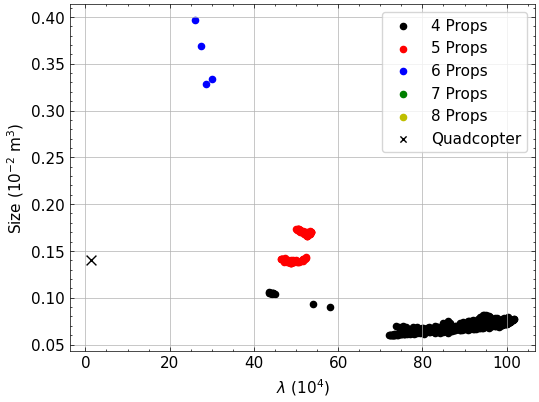

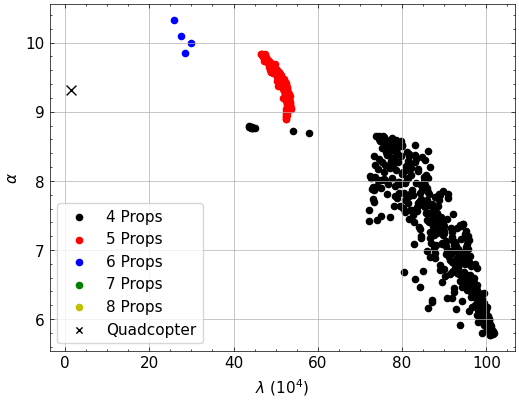

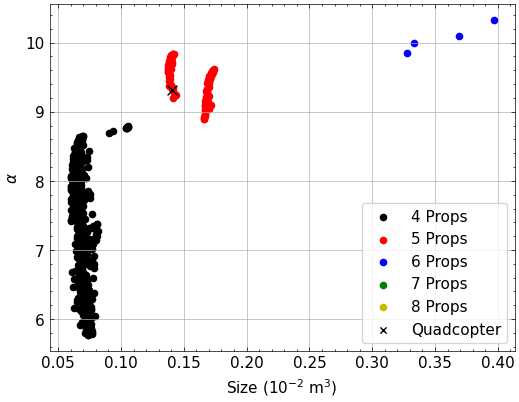

In [488]:
data_3d.plot_2d()

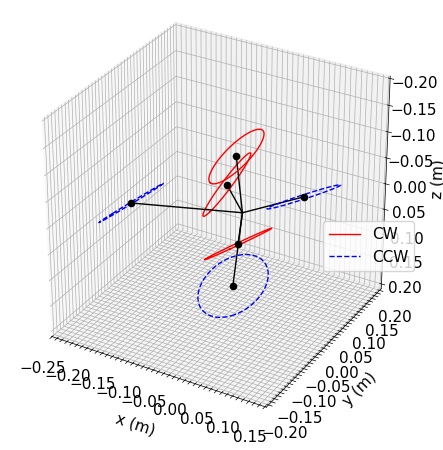

In [489]:
# Plot max alpha drone
alpha_max = data_3d.objectives_optim.iloc[data_3d.objectives_optim['alpha'].idxmax()]["drone"]
alpha_drone = Phenotype_3D(alpha_max)
alpha_drone.plot_drone(legend=True, projection='3d')
# plt.xlim([-0.42, 0.42])
# plt.ylim([-0.3, 0.4])
# alpha_drone.props
# plt.savefig("alpha-drone.eps", format='eps')

0.29448794771128384


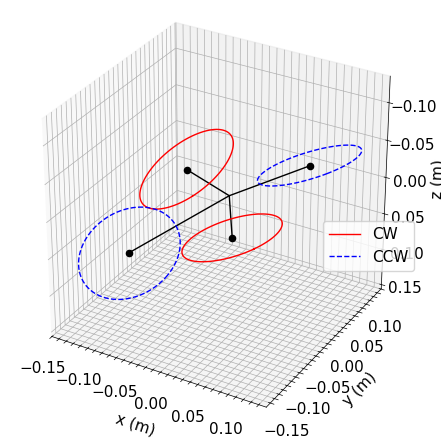

In [490]:
# Plot max ctrl drone
ctrl_max = data_3d.objectives_optim.iloc[data_3d.objectives_optim['ctrl'].idxmax()]["drone"]
print(ctrl_max[3*6 + 2])
ctrl_drone = Phenotype_3D(ctrl_max)
ctrl_drone.plot_drone(legend=True)
# plt.xlim([-0.42, 0.42])
# plt.ylim([-0.3, 0.4])
# ctrl_drone.props
# plt.savefig("alpha-drone.eps", format='eps')

In [480]:
load_path_2d = "./Logs/half_motor_full_arm_newman/500x2000/2D/run4"

data_2d = DataLoader(load_path_2d, num_gen=2000)

optim_2d = data_2d.objectives_optim

print("Quad Alpha: ", quad_alpha)
print("Quad Size: ", quad_size)
print("Quad_Control: ", quad_ctrl)

print("Alpha: ", max(data_2d.alpha_optim))
print("Size: ", min(data_2d.size_optim))
print("Control: ", max(data_2d.ctrl_optim))

print(f"Improvement in alpha: {((max(data_2d.alpha_optim) - quad_alpha)/quad_alpha)*100} %")
print(f"Improvement in size: {((quad_size - min(data_2d.size_optim))/quad_size) * 100} %")
print(f"Improvement in control: {((max(data_2d.ctrl_optim) - quad_ctrl)/quad_ctrl) * 100} %")

Quad Alpha:  9.309102118333213
Quad Size:  0.0014083571422497882
Quad_Control:  13639.735001978863
Alpha:  9.8379002662722
Size:  0.0012399352002619
Control:  935640.9800798816
Improvement in alpha: 5.680442014891854 %
Improvement in size: 11.958752289127577 %
Improvement in control: 6759.671246869079 %


In [481]:
data_2d.plot_3d()

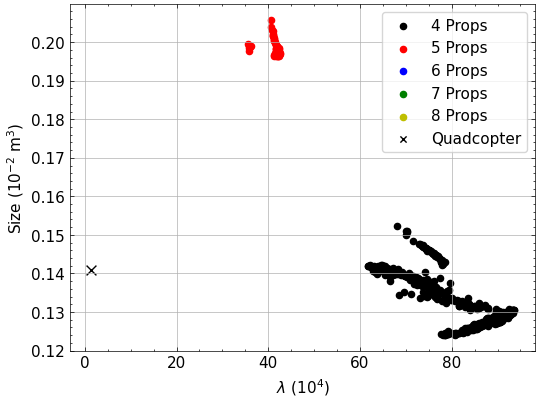

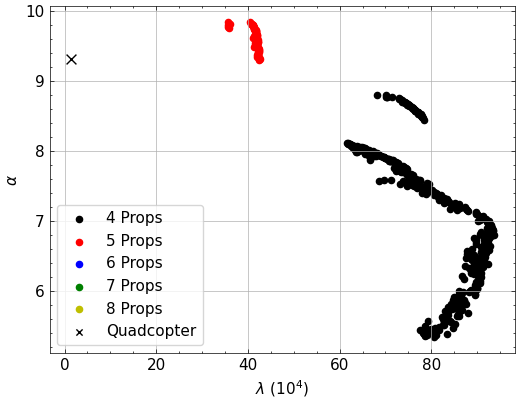

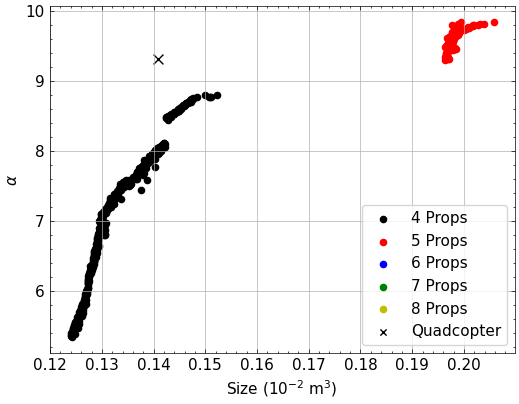

In [482]:
data_2d.plot_2d()

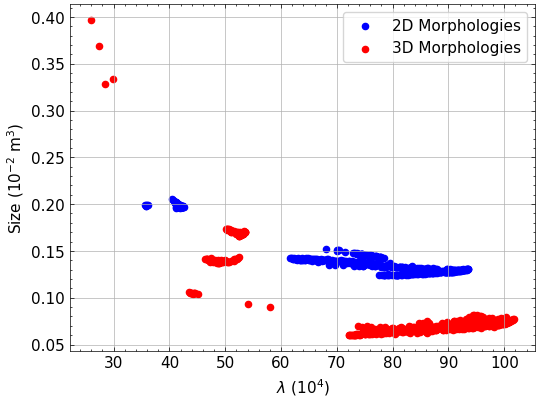

In [483]:
plt.scatter(optim_2d["ctrl"]*1e-4, optim_2d["size"]*1e2, color='b', s=20)
plt.scatter(optim_3d["ctrl"]*1e-4, optim_3d["size"]*1e2, color='r', s=20)
plt.xlabel(r"$\lambda$ ($10^4$)")
plt.ylabel(r"Size ($10^{-2}$ m$^3$)")

plt.scatter([], [], color="b", label="2D Morphologies", s=20)
plt.scatter([], [], color="r", label="3D Morphologies", s=20)

plt.legend()

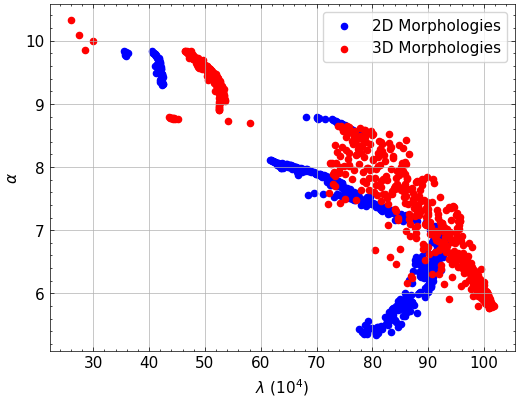

In [484]:
plt.scatter(optim_2d["ctrl"]*1e-4, optim_2d["alpha"], color='b', s=20)
plt.scatter(optim_3d["ctrl"]*1e-4, optim_3d["alpha"], color='r', s=20)
plt.xlabel(r"$\lambda$ ($10^4$)")
plt.ylabel(r"$\alpha$")
        
plt.scatter([], [], color="b", label="2D Morphologies", s=20)
plt.scatter([], [], color="r", label="3D Morphologies", s=20)

plt.legend()

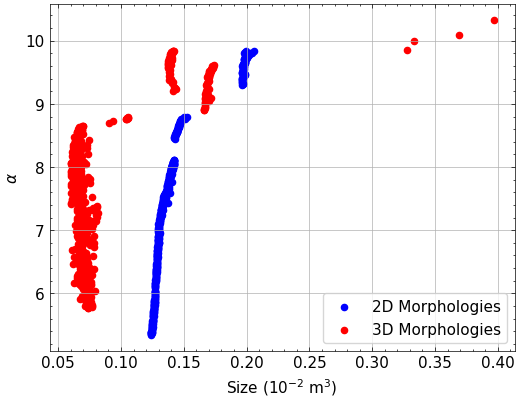

In [485]:
plt.scatter(optim_2d["size"]*1e2, optim_2d["alpha"], color='b', s=20)
plt.scatter(optim_3d["size"]*1e2, optim_3d["alpha"], color='r', s=20)
plt.xlabel(r"Size ($10^{-2}$ m$^3$)")
plt.ylabel(r"$\alpha$")

plt.scatter([], [], color="b", label="2D Morphologies", s=20)
plt.scatter([], [], color="r", label="3D Morphologies", s=20)

plt.legend()

[{'loc': [np.float64(0.1014227820969922), np.float64(-0.1495474290462525), 0],
  'dir': [np.float64(-0.27765988718951884),
   np.float64(0.2734943883395626),
   np.float64(-0.9209266021745013),
   'cw'],
  'propsize': 5,
  'constants': [1.08e-06, 1.22e-08],
  'wmax': 3142},
 {'loc': [np.float64(-0.14797710194548916),
   np.float64(0.08419571702663615),
   0],
  'dir': [np.float64(-0.533452060420485),
   np.float64(-0.0813513290347286),
   np.float64(-0.8419090571418166),
   'cw'],
  'propsize': 5,
  'constants': [1.08e-06, 1.22e-08],
  'wmax': 3142},
 {'loc': [np.float64(0.07784357201256233), np.float64(0.16766247179938143), 0],
  'dir': [np.float64(-0.2893683244631761),
   np.float64(-0.1154402823778714),
   np.float64(-0.9502312950023754),
   'cw'],
  'propsize': 5,
  'constants': [1.08e-06, 1.22e-08],
  'wmax': 3142},
 {'loc': [np.float64(-0.16153698510791573),
   np.float64(-0.10335296085545802),
   0],
  'dir': [np.float64(-0.4704964589651798),
   np.float64(-0.7599602885415779),


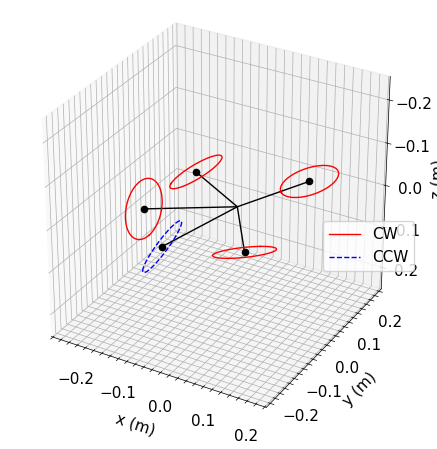

In [401]:
# Plot max alpha drone
alpha_max = data_2d.objectives_optim.iloc[data_2d.objectives_optim['alpha'].idxmax()]["drone"]
alpha_drone = Phenotype_2D(alpha_max)
alpha_drone.plot_drone(legend=True)
# plt.xlim([-0.42, 0.42])
# plt.ylim([-0.3, 0.4])
alpha_drone.props
# print(data_2d.objectives_optim.iloc[data_2d.objectives_optim['alpha'].idxmax()]["ctrl"])
# plt.savefig("alpha-drone.eps", format='eps')


In [402]:
sim = Hover(alpha_drone.drone)
sim.compute_hover(verbose=True)
sim.Bf


Testing static hover...
----------Static Hover Achieved----------
Optimum input = [0.32309317 0.32357796 0.32345858 0.29172193 0.31898717]
Thrust vector direction: [-0.50851335 -0.18843195 -0.84018306]
Resultant specific force: 9.81
Resultant specific torque: 0.00
Max thrust to weight: 8.80
Moments rank: 3
Moments gram eig: [690782.10536553 393159.30198374  32043.84114494]
Input cost: 0.05965


array([[ -5.49794858, -10.56289414,  -5.72978756,  -9.31630911,
        -14.84912086],
       [  5.41546746,  -1.61083917,  -2.28583517, -15.04798777,
         -5.52812328],
       [-18.23528473, -16.67065685, -18.8155475 ,  -8.87945855,
        -11.87534412]])

In [403]:
for prop in alpha_drone.props:
    prop_loc = np.asarray(prop["loc"])
    print(prop_loc)

[ 0.10142278 -0.14954743  0.        ]
[-0.1479771   0.08419572  0.        ]
[0.07784357 0.16766247 0.        ]
[-0.16153699 -0.10335296  0.        ]
[-0.05115572 -0.21240766  0.        ]


In [404]:
for prop in alpha_drone.props:
    prop_loc = np.asarray(prop["loc"])
    prop_length = np.linalg.norm(prop_loc)
    prop_angle = np.arctan2(prop_loc[1],prop_loc[0]) / np.pi * 180
    print(f"length: {prop_length}")
    print(f"angle: {prop_angle}")

    prop_dir = prop["dir"][0:4]
    print(f"inclination: {np.arccos(-prop_dir[2])/np.pi*180}")
    print(f"azimuth: {np.arctan2(prop_dir[1],prop_dir[0])/np.pi*180 - prop_angle}")
    print(prop_dir[-1])
    print(" ")

length: 0.1806959165632635
angle: -55.85495421459483
inclination: 22.93807703920201
azimuth: 191.287974459988
cw
 
length: 0.1702531687394249
angle: 150.3610755694444
inclination: 32.65773620305984
azimuth: -321.6902856807893
cw
 
length: 0.18485217378638896
angle: 65.09515204372512
inclination: 18.152383308898493
azimuth: -223.3461723213103
cw
 
length: 0.19177078003529324
angle: -147.3884849197704
inclination: 63.356716829002224
azimuth: 25.62656023032767
cw
 
length: 0.2184809440505626
angle: -103.5410945460762
inclination: 53.14915059396829
azimuth: -56.03929938448208
ccw
 


[{'loc': [np.float64(0.10170302079207713), np.float64(-0.02433574606011677), 0], 'dir': [np.float64(-0.10938436760208327), np.float64(-0.4534896081849394), np.float64(-0.8845237336513715), 'cw'], 'propsize': 5, 'constants': [1.08e-06, 1.22e-08], 'wmax': 3142}, {'loc': [np.float64(-0.10983021486028337), np.float64(-0.001353072201210864), 0], 'dir': [np.float64(-0.15640986484269767), np.float64(0.3901806294491352), np.float64(-0.9073560660416427), 'cw'], 'propsize': 5, 'constants': [1.08e-06, 1.22e-08], 'wmax': 3142}, {'loc': [np.float64(0.009008543470589755), np.float64(0.09981072600275873), 0], 'dir': [np.float64(-0.2361172037719415), np.float64(0.12274402815900383), np.float64(-0.963941165027317), 'cw'], 'propsize': 5, 'constants': [1.08e-06, 1.22e-08], 'wmax': 3142}, {'loc': [np.float64(-0.016999032140932138), np.float64(-0.11830932150819297), 0], 'dir': [np.float64(0.47070966022882105), np.float64(-0.6660234489822111), np.float64(-0.578658086587501), 'ccw'], 'propsize': 5, 'constant

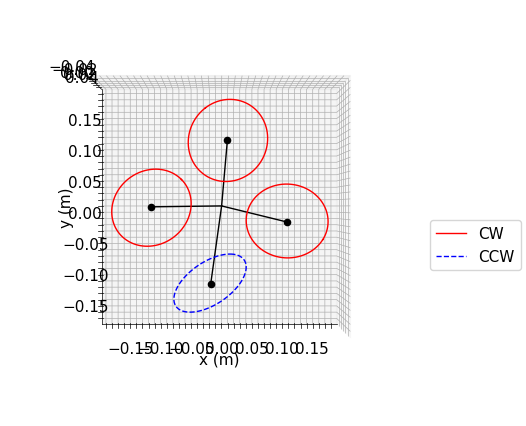

In [405]:
# Plot min size drone
size_min = data_2d.objectives_optim.iloc[data_2d.objectives_optim['size'].idxmin()]["drone"]
vol_drone = Phenotype_2D(size_min)
print(vol_drone.props)
vol_drone.plot_drone(legend=True, projection='2d')
# plt.savefig("size-drone.eps", format='eps')

In [406]:
for prop in vol_drone.props:
    prop_loc = np.asarray(prop["loc"])
    prop_length = np.linalg.norm(prop_loc)
    prop_angle = np.arctan2(prop_loc[1],prop_loc[0]) / np.pi * 180
    print(f"length: {prop_length}")
    print(f"angle: {prop_angle}")

    prop_dir = prop["dir"][0:3]
    print(f"inclination: {np.arccos(-prop_dir[2])/np.pi*180}")
    print(f"azimuth: {np.arctan2(prop_dir[1],prop_dir[0])/np.pi*180 - prop_angle}")
    print(" ")

length: 0.1045740549779732
angle: -13.456852454363874
inclination: 27.807031330001188
azimuth: -90.10419272246078
 
length: 0.10983854924678174
angle: -179.29417050814416
inclination: 24.857501129660506
azimuth: 291.13830563073105
 
length: 0.10021644017155709
angle: 84.84267077195189
inclination: 15.433243287589548
azimuth: 67.68994969670216
 
length: 0.11952431823464803
angle: -98.17646585430879
inclination: 54.643785153957275
azimuth: 43.427086810267184
 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


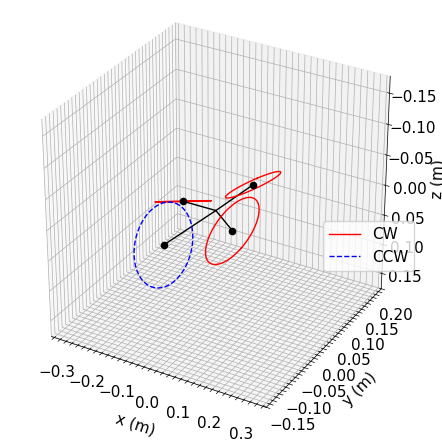

In [407]:
# Plot max ctrl drone
ctrl_max = data_2d.objectives_optim.iloc[data_2d.objectives_optim['ctrl'].idxmax()]["drone"]
ctrl_drone = Phenotype_2D(ctrl_max)
ctrl_drone.plot_drone(legend=True, projection='3d')
plt.xlim([-0.35, 0.35])
plt.ylim([-0.18, 0.2])
plt.savefig("ctrl-drone.eps", format='eps')

In [200]:
sim = Hover(ctrl_drone.drone)
sim.compute_hover(verbose=True)
sim.Bf

Testing static hover...
----------Static Hover Achieved----------
Optimum input = [0.54245202 0.44141473 0.20005453 0.3539172 ]
Thrust vector direction: [ 0.66265221 -0.3139269  -0.67995731]
Resultant specific force: 9.81
Resultant specific torque: 0.00
Max thrust to weight: 3.29
Moments rank: 3
Moments gram eig: [ 89289.99905747 926451.05147252 994971.6452251 ]
Input cost: 0.15482


array([[ 12.31098265,  10.04653916,   0.89832925,   4.8672968 ],
       [-17.93134243,  18.64619278,  16.5828538 , -16.47596937],
       [ -7.04471797,  -8.6085964 , -15.71379492, -15.08553086]])

In [17]:
for prop in ctrl_drone.props:
    prop_loc = np.asarray(prop["loc"])
    print(prop_loc)

[-0.05961852  0.09331001  0.        ]
[-0.08409903 -0.06269724  0.        ]
[0.09120509 0.05791518 0.        ]
[ 0.06118462 -0.08661747  0.        ]


In [18]:
for prop in ctrl_drone.props:
    prop_loc = np.asarray(prop["loc"])
    prop_length = np.linalg.norm(prop_loc)
    prop_angle = np.arctan2(prop_loc[1],prop_loc[0]) / np.pi * 180
    print(f"length: {prop_length}")
    print(f"angle: {prop_angle}")

    prop_dir = prop["dir"][0:4]
    print(f"inclination: {np.arccos(-prop_dir[2])/np.pi*180}")
    print(f"azimuth: {np.arctan2(prop_dir[1],prop_dir[0])/np.pi*180 - prop_angle}")
    print(prop_dir[-1])
    print(" ")

length: 0.11072996826637284
angle: 122.57571122299777
inclination: 7.695666884686719
azimuth: -60.62605761855283
cw
 
length: 0.10489800151770046
angle: -143.2948486917721
inclination: 9.607759935255604
azimuth: 32.52080036241996
ccw
 
length: 0.10803951715375748
angle: 32.41552227033686
inclination: 12.038586149730314
azimuth: 68.94379818673585
ccw
 
length: 0.10604783647346688
angle: -54.76348401535952
inclination: 10.65388333584677
azimuth: -61.28576135309426
cw
 
